Loading datasets...

Load Dataset Columns:
Index(['DATETIME', 'LOAD'], dtype='object')

Weather Dataset Columns:
Index(['DATETIME', 'ACT_HEAT_INDEX', 'ACT_HUMIDITY', 'ACT_RAIN', 'ACT_TEMP',
       'COOL_FACTOR'],
      dtype='object')

Merged Data Shape: (283391, 6)
Start: 2013-04-01 00:15:00
End  : 2021-04-30 23:45:00


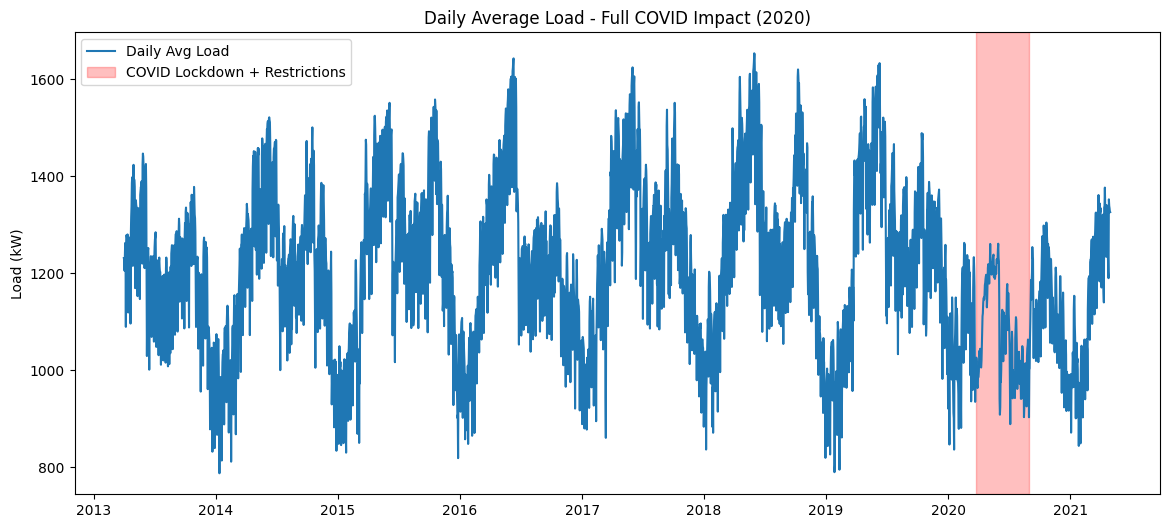

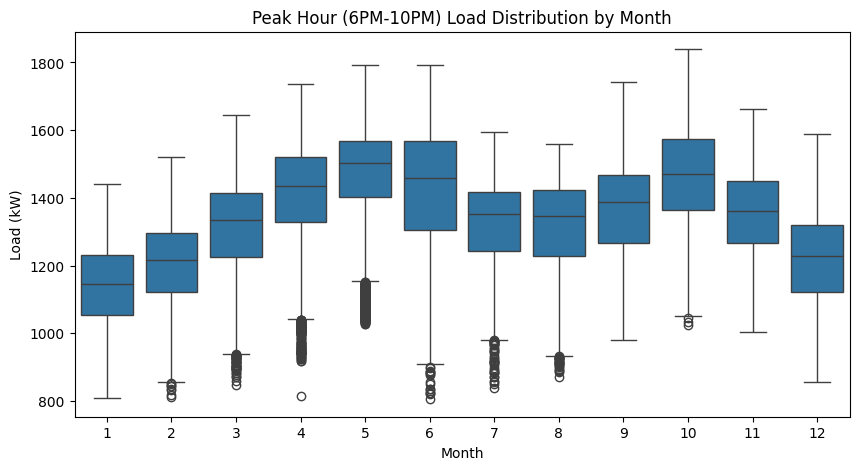

In [4]:
# ==========================================
# IMPORTS
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

# ==========================================
# FILE PATHS
# ==========================================
BASE_PATH = Path.home() / "Downloads"

LOAD_DATA_PATH = BASE_PATH / "Electric_Load_Data_Train.csv"
WEATHER_DATA_PATH = BASE_PATH / "External_Factor_Data_Train.csv"

# ==========================================
# LOAD DATASETS
# ==========================================
print("Loading datasets...\n")

load_df = pd.read_csv(LOAD_DATA_PATH)
weather_df = pd.read_csv(WEATHER_DATA_PATH)

print("Load Dataset Columns:")
print(load_df.columns)
print("\nWeather Dataset Columns:")
print(weather_df.columns)

# ==========================================
# CLEAN COLUMN NAMES
# ==========================================
load_df.columns = load_df.columns.str.strip()
weather_df.columns = weather_df.columns.str.strip()

# ==========================================
# FIX DATETIME PARSING
# Format example: 01APR2013:00:15:00
# ==========================================
DATETIME_FORMAT = "%d%b%Y:%H:%M:%S"

load_df["DATETIME"] = pd.to_datetime(
    load_df["DATETIME"],
    format=DATETIME_FORMAT
)

weather_df["DATETIME"] = pd.to_datetime(
    weather_df["DATETIME"],
    format=DATETIME_FORMAT
)

# ==========================================
# RENAME COLUMNS
# ==========================================
load_df.rename(columns={
    "DATETIME": "DateTime",
    "LOAD": "Load"
}, inplace=True)

weather_df.rename(columns={
    "DATETIME": "DateTime"
}, inplace=True)

# ==========================================
# MERGE DATA
# ==========================================
df = pd.merge(load_df, weather_df, on="DateTime", how="inner")

# ==========================================
# SORT + SET INDEX
# ==========================================
df = df.sort_values("DateTime")
df.set_index("DateTime", inplace=True)

print("\nMerged Data Shape:", df.shape)
print("Start:", df.index.min())
print("End  :", df.index.max())

# ==========================================
# ADD COVID FEATURE (Full Lockdown Duration)
# March 25, 2020 → August 31, 2020
# ==========================================
df["covid_period"] = (
    (df.index >= "2020-03-25") &
    (df.index <= "2020-08-31")
).astype(int)

# ==========================================
# VISUALIZATION 1: STRUCTURAL BREAK (FULL LOCKDOWN)
# ==========================================
def plot_structural_break_daily(data):
    daily = data["Load"].resample("D").mean()

    plt.figure(figsize=(14,6))
    plt.plot(daily.index, daily.values, label="Daily Avg Load")

    # Strict + Unlock phases
    plt.axvspan(pd.Timestamp("2020-03-25"),
                pd.Timestamp("2020-08-31"),
                color="red", alpha=0.25,
                label="COVID Lockdown + Restrictions")

    plt.title("Daily Average Load - Full COVID Impact (2020)")
    plt.ylabel("Load (kW)")
    plt.legend()
    plt.show()

# ==========================================
# VISUALIZATION 2: PEAK HOUR VOLATILITY
# ==========================================
def plot_peak_volatility(data):
    peak_data = data[(data.index.hour >= 18) &
                     (data.index.hour <= 22)]

    plt.figure(figsize=(10,5))
    sns.boxplot(x=peak_data.index.month,
                y=peak_data["Load"])

    plt.title("Peak Hour (6PM-10PM) Load Distribution by Month")
    plt.xlabel("Month")
    plt.ylabel("Load (kW)")
    plt.show()

# ==========================================
# RUN PLOTS
# ==========================================
plot_structural_break_daily(df)
plot_peak_volatility(df)

In [6]:
import numpy as np

def calculate_penalties(actual, forecast):
    """
    Maharashtra ABT Penalty Structure
    Under-forecasting (Actual > Forecast) = ₹4 per unit
    Over-forecasting (Forecast > Actual) = ₹2 per unit
    """
    deviation = actual - forecast

    # Under-forecasting
    under_mask = deviation > 0
    under_penalty = deviation[under_mask] * 4

    # Over-forecasting
    over_mask = deviation < 0
    over_penalty = np.abs(deviation[over_mask]) * 2

    total_penalty = under_penalty.sum() + over_penalty.sum()

    return total_penalty, under_penalty.mean(), over_penalty.mean()


# ==========================================
# CREATE SIMPLE NAIVE FORECAST (Previous value)
# ==========================================
df["Naive_Forecast"] = df["Load"].shift(1)

# Drop first NA row
df_penalty = df.dropna()

# ==========================================
# CALCULATE PENALTY
# ==========================================
total_cost, avg_under, avg_over = calculate_penalties(
    df_penalty["Load"],
    df_penalty["Naive_Forecast"]
)

print("Total Penalty Cost: ₹", round(total_cost, 2))
print("Average Under-Forecast Penalty: ₹", round(avg_under, 2))
print("Average Over-Forecast Penalty: ₹", round(avg_over, 2))

Total Penalty Cost: ₹ 12718534.14
Average Under-Forecast Penalty: ₹ 71.99
Average Over-Forecast Penalty: ₹ 26.62


                         QuantReg Regression Results                          
Dep. Variable:                   Load   Pseudo R-squared:               0.5107
Model:                       QuantReg   Bandwidth:                       8.715
Method:                 Least Squares   Sparsity:                        303.7
Date:                Sat, 28 Feb 2026   No. Observations:               283390
Time:                        15:59:24   Df Residuals:                   283357
                                        Df Model:                           32
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            92.5206      5.152     17.960      0.000      82.424     102.618
C(Hour)[T.1]        -98.8222      1.859    -53.163      0.000    -102.466     -95.179
C(Hour)[T.2]       -172.7368      1.860    -92.884      0.000    -176.382    -169.092
C(Hour)[T.3]     

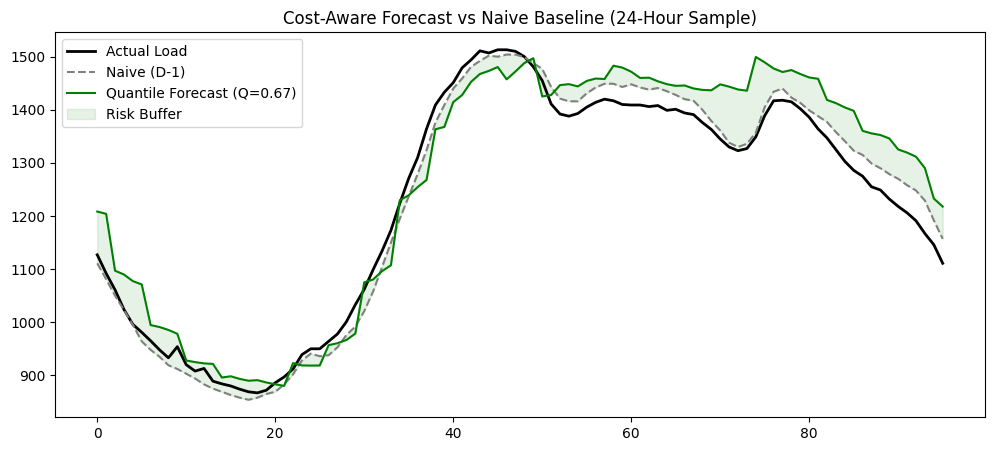

In [8]:
# ==========================================
# IMPORTS
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# ==========================================
# FEATURE ENGINEERING
# ==========================================

# Rename weather columns to match formula
df.rename(columns={
    "ACT_TEMP": "Temperature",
    "ACT_HUMIDITY": "Humidity",
    "ACT_HEAT_INDEX": "Heat_Index"
}, inplace=True)

# Time features
df["Hour"] = df.index.hour
df["DayOfWeek"] = df.index.dayofweek

# Drop missing values
df_model = df.dropna().copy()

# ==========================================
# FIT QUANTILE REGRESSION MODEL (Q = 0.67)
# ==========================================

def fit_quantile_model(data):
    formula = "Load ~ Temperature + Humidity + Heat_Index + C(Hour) + C(DayOfWeek)"
    
    model = smf.quantreg(formula, data)
    result = model.fit(q=0.67)   # Risk-adjusted quantile
    
    print(result.summary())
    return result

quant_model = fit_quantile_model(df_model)

# ==========================================
# GENERATE SMART FORECAST
# ==========================================
df_model["Smart_Forecast"] = quant_model.predict(df_model)

# ==========================================
# CREATE NAIVE BASELINE (D-1 for 15-min data)
# 96 intervals = 24 hours
# ==========================================
df_model["Naive_Forecast"] = df_model["Load"].shift(96)
df_model = df_model.dropna()

# ==========================================
# VISUALIZATION FUNCTION
# ==========================================

def visualize_strategy(actual, naive, smart_forecast):
    plt.figure(figsize=(12, 5))
    
    plt.plot(actual[:96], label="Actual Load", color="black", linewidth=2)
    plt.plot(naive[:96], label="Naive (D-1)", linestyle="--", color="gray")
    plt.plot(smart_forecast[:96], label="Quantile Forecast (Q=0.67)", color="green")
    
    plt.fill_between(
        range(96),
        naive[:96],
        smart_forecast[:96],
        color="green",
        alpha=0.1,
        label="Risk Buffer"
    )
    
    plt.title("Cost-Aware Forecast vs Naive Baseline (24-Hour Sample)")
    plt.legend()
    plt.show()

# ==========================================
# RUN VISUALIZATION
# ==========================================

visualize_strategy(
    df_model["Load"].values,
    df_model["Naive_Forecast"].values,
    df_model["Smart_Forecast"].values
)

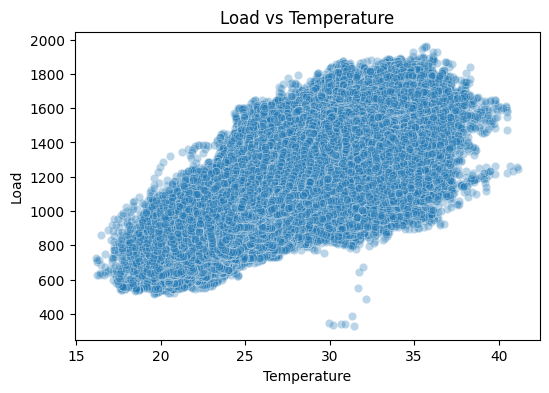

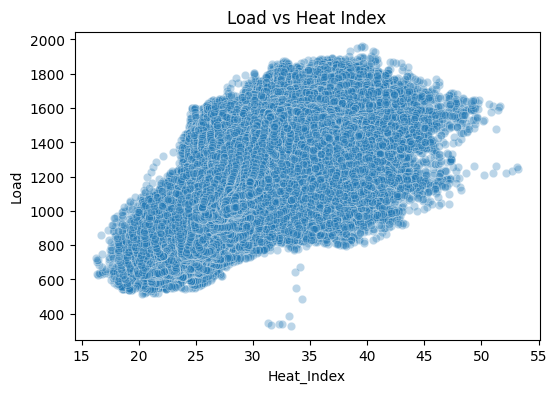

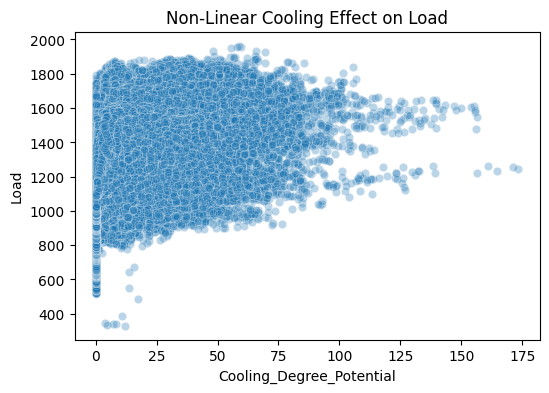

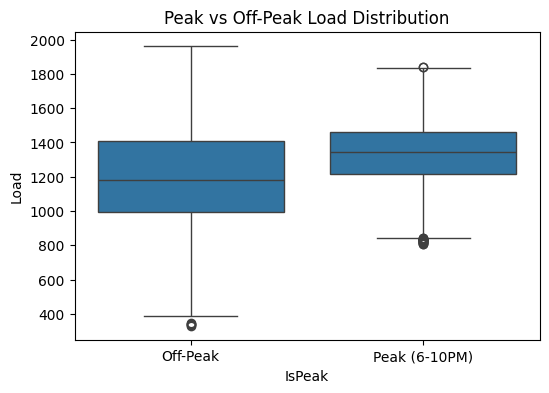

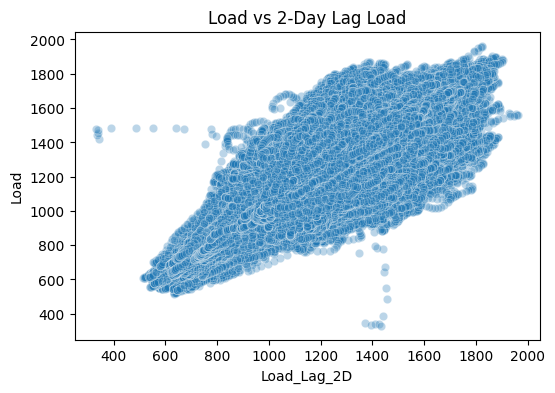

Visualization Completed.


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

def visualize_engineered_features(data):

    # --------------------------------------
    # 1. Load vs Temperature
    # --------------------------------------
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=data["Temperature"], y=data["Load"], alpha=0.3)
    plt.title("Load vs Temperature")
    plt.show()

    # --------------------------------------
    # 2. Load vs Heat Index
    # --------------------------------------
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=data["Heat_Index"], y=data["Load"], alpha=0.3)
    plt.title("Load vs Heat Index")
    plt.show()

    # --------------------------------------
    # 3. Cooling Degree Potential Effect
    # --------------------------------------
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=data["Cooling_Degree_Potential"], y=data["Load"], alpha=0.3)
    plt.title("Non-Linear Cooling Effect on Load")
    plt.show()

    # --------------------------------------
    # 4. Peak vs Non-Peak Comparison
    # --------------------------------------
    plt.figure(figsize=(6,4))
    sns.boxplot(x=data["IsPeak"], y=data["Load"])
    plt.xticks([0,1], ["Off-Peak", "Peak (6-10PM)"])
    plt.title("Peak vs Off-Peak Load Distribution")
    plt.show()

    # --------------------------------------
    # 5. 2-Day Lag Relationship
    # --------------------------------------
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=data["Load_Lag_2D"], y=data["Load"], alpha=0.3)
    plt.title("Load vs 2-Day Lag Load")
    plt.show()

    print("Visualization Completed.")


# ==========================================
# RUN VISUALIZATION
# ==========================================

visualize_engineered_features(df_features)

Recency weights successfully applied.
Weight Range: 0.0003 to 1.0


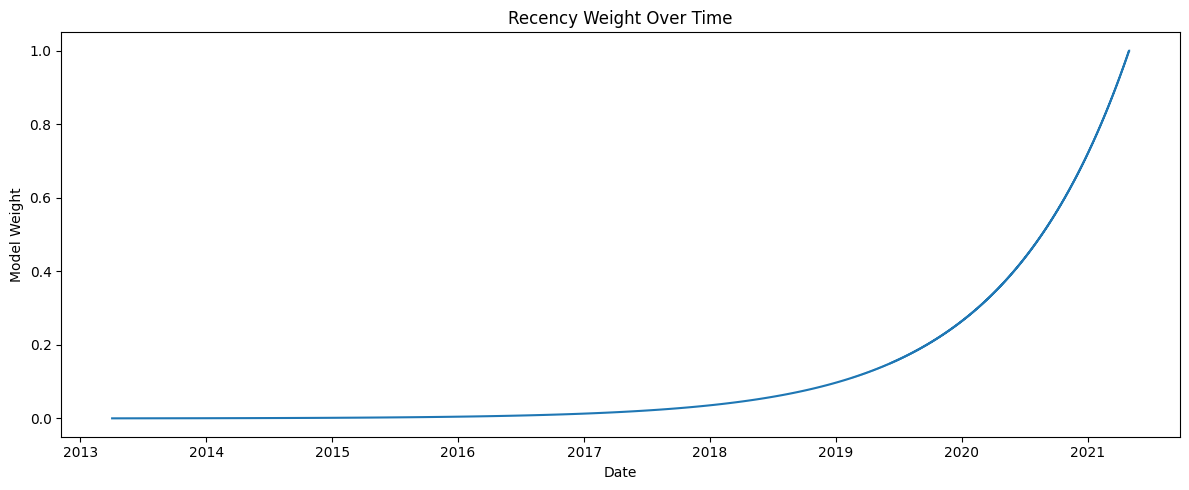

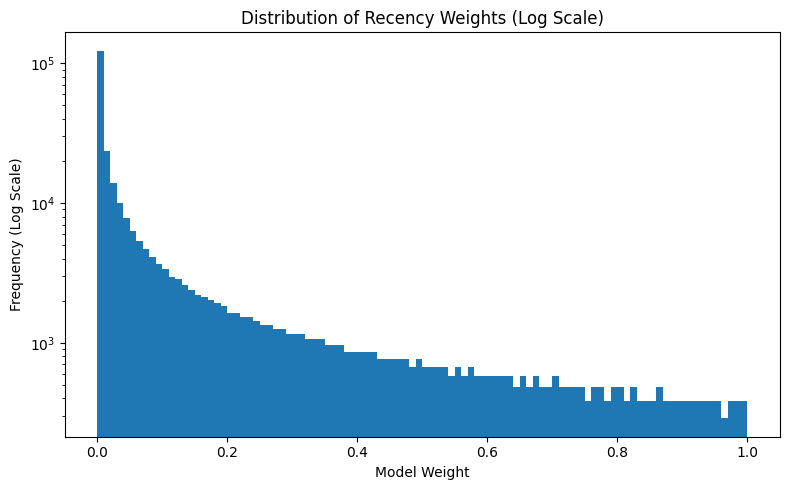

Improved visualization completed.


In [14]:
# ==========================================
# IMPORTS
# ==========================================
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# APPLY RECENCY WEIGHTS
# ==========================================
def apply_recency_weights(df):
    """
    Applies exponential decay weighting so that
    recent data has higher importance.
    """

    df = df.copy()

    # Ensure DateTime index
    if not isinstance(df.index, pd.DatetimeIndex):
        raise ValueError("DataFrame index must be DateTimeIndex.")

    # Most recent date in dataset
    max_date = df.index.max()

    # Days difference from most recent date
    df["Days_From_Present"] = (max_date - df.index).days

    # Exponential decay (1-year decay scale)
    df["Model_Weight"] = np.exp(-df["Days_From_Present"] / 365)

    print("Recency weights successfully applied.")
    print("Weight Range:",
          round(df["Model_Weight"].min(), 4),
          "to",
          round(df["Model_Weight"].max(), 4))

    return df


# ==========================================
# CALL FUNCTION
# ==========================================
df_weighted = apply_recency_weights(df_features)

# ==========================================
# VISUALIZATION
# ==========================================
def visualize_recency_weights(data):

    # --------------------------------------
    # 1️⃣ Weight Over Time
    # --------------------------------------
    plt.figure(figsize=(12,5))
    plt.plot(data.index, data["Model_Weight"])
    plt.title("Recency Weight Over Time")
    plt.xlabel("Date")
    plt.ylabel("Model Weight")
    plt.tight_layout()
    plt.show()

    # --------------------------------------
    # 2️⃣ Improved Distribution Plot
    # --------------------------------------
    plt.figure(figsize=(8,5))
    plt.hist(data["Model_Weight"], bins=100, log=True)
    plt.title("Distribution of Recency Weights (Log Scale)")
    plt.xlabel("Model Weight")
    plt.ylabel("Frequency (Log Scale)")
    plt.tight_layout()
    plt.show()

    print("Improved visualization completed.")

# ==========================================
# RUN VISUALIZATION
# ==========================================
visualize_recency_weights(df_weighted)